Regression Equation:
y = 1.12x + 18.36

Actual vs Predicted
Actual = 105  Predicted = 119.22
Actual = 35  Predicted = 40.78

MAE = 10.0
R² Score = 0.9038
Predicted Umbrella Sales = 74


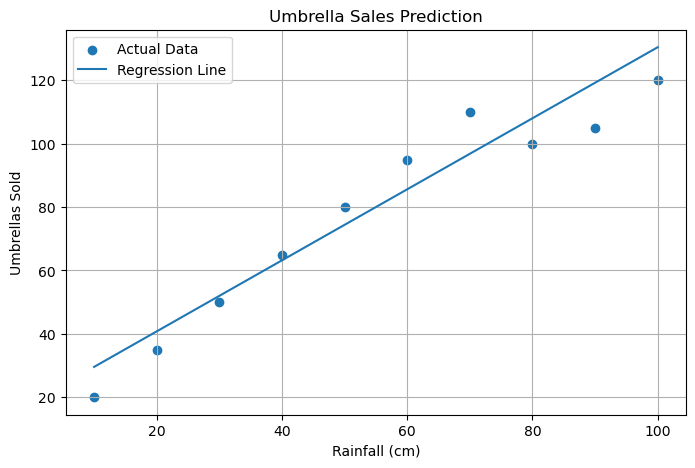

In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


class LinearRegression:

    def __init__(self):
        self.m = 0
        self.c = 0

    def fit(self, X, Y):

        n = len(X)

        sum_x = sum(X)
        sum_y = sum(Y)

        sum_xy = sum(x * y for x, y in zip(X, Y))
        sum_x2 = sum(x ** 2 for x in X)

        self.m = ((n * sum_xy) - (sum_x * sum_y)) / \
                 ((n * sum_x2) - (sum_x ** 2))

        self.c = (sum_y - self.m * sum_x) / n

    def predict(self, X):

        predictions = []

        for x in X:
            predictions.append(self.m * x + self.c)

        return predictions

    def equation(self):
        return f"y = {self.m:.2f}x + {self.c:.2f}"


# Dataset

x = [10,20,30,40,50,60,70,80,90,100]      # Rainfall (cm)
y = [20,35,50,65,80,95,110,100,105,120]   # Umbrellas sold


# Train-Test Split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)


# Training

model = LinearRegression()
model.fit(x_train, y_train)

print("Regression Equation:")
print(model.equation())


# Predictions on Test Data

y_pred = model.predict(x_test)

print("\nActual vs Predicted")

for actual, pred in zip(y_test, y_pred):
    print(f"Actual = {actual}  Predicted = {pred:.2f}")


# Mean Absolute Error

mae = sum(abs(a - p) for a, p in zip(y_test, y_pred)) / len(y_test)

print("\nMAE =", round(mae, 2))


# R² Score

mean_y = sum(y_test) / len(y_test)

ss_total = sum((y - mean_y) ** 2 for y in y_test)

ss_residual = sum((a - p) ** 2
                  for a, p in zip(y_test, y_pred))

r2 = 1 - (ss_residual / ss_total)

print("R² Score =", round(r2, 4))


# User Prediction

rainfall = float(input("\nEnter expected rainfall: "))

predicted_sales = model.predict([rainfall])[0]

print("Predicted Umbrella Sales =", round(predicted_sales))


# Visualization

all_predictions = model.predict(x)

plt.figure(figsize=(8, 5))

plt.scatter(
    x,
    y,
    label="Actual Data"
)

plt.plot(
    x,
    all_predictions,
    label="Regression Line"
)

plt.xlabel("Rainfall (cm)")
plt.ylabel("Umbrellas Sold")
plt.title("Umbrella Sales Prediction")
plt.legend()
plt.grid(True)

plt.show()